In [2]:
%run 03_preprocessing.ipynb

Original rows: 2126
Rows after removing duplicates: 2113
Missing values in each column:
0

Rows: 2113
Columns: 22
Class distribution:
fetal_health
1.0    1646
2.0     292
3.0     175
Name: count, dtype: int64

Class percentages:
fetal_health
1.0    77.90
2.0    13.82
3.0     8.28
Name: proportion, dtype: float64
Training samples: 1690
Testing samples: 423

Training class distribution:
fetal_health
1.0    1305
2.0     238
3.0     147
Name: count, dtype: int64

Testing class distribution:
fetal_health
1.0    341
2.0     54
3.0     28
Name: count, dtype: int64
Original training shape: (1690, 21)
Scaled training shape: (1690, 21)
Original testing shape: (423, 21)
Scaled testing shape: (423, 21)

Training samples: 1690 (79.98%)
Testing samples: 423 (20.02%))


In [32]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(1690, 21)
(423, 21)


### Decision Tree Hyperparameter Tuning

In [11]:
# Import and use the DecisionTreeClassifier and GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(
    random_state=42
)

dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 5]
}

dt_grid_search = GridSearchCV(
    estimator=dt,
    param_grid=dt_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
#run the grid search for Decision Tree
dt_grid_search.fit(X_train_scaled, y_train) 

#see the best parameters and best score for Decision Tree
print("Best Decision Tree Parameters:", dt_grid_search.best_params_)

print(
    f"Best Decision Tree CV Accuracy: "
    f"{dt_grid_search.best_score_:.4f} "
    f"({dt_grid_search.best_score_ * 100:.2f}%)"
)

#test the tuned Decision Tree model on the test set
dt_tuned = dt_grid_search.best_estimator_
dt_tuned_pred = dt_tuned.predict(X_test_scaled)

from sklearn.metrics import accuracy_score

dt_tuned_accuracy = accuracy_score(
    y_test,
    dt_tuned_pred
)

print(
    f"Tuned Decision Tree Test Accuracy: "
    f"{dt_tuned_accuracy:.4f} "
    f"({dt_tuned_accuracy * 100:.2f}%)"
)

Best Decision Tree Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best Decision Tree CV Accuracy: 0.9225 (92.25%)
Tuned Decision Tree Test Accuracy: 0.9362 (93.62%)


### Gradient Boosting Hyperparameter Tuning

In [6]:
# Import and use the GradientBoostingClassifier and GridSearchCV
#see the best parameters and best score for Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

gb = GradientBoostingClassifier(
    random_state=42
)

gb_param_grid = {
    "learning_rate": [0.05, 0.08, 0.1, 0.12, 0.15],
    "n_estimators": [200, 300, 400, 500],
    "max_depth": [2, 3, 4, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

gb_grid_search = GridSearchCV(
    estimator=gb,
    param_grid=gb_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

gb_grid_search.fit(X_train_scaled, y_train)

print("Best Gradient Boosting Parameters:", gb_grid_search.best_params_)

print(
    f"Best Gradient Boosting CV Accuracy: "
    f"{gb_grid_search.best_score_:.4f} "
    f"({gb_grid_search.best_score_ * 100:.2f}%)"
)

#test the tuned Gradient Boosting model
gb_tuned = gb_grid_search.best_estimator_
gb_tuned_pred = gb_tuned.predict(X_test_scaled)

gb_tuned_accuracy = accuracy_score(
    y_test,
    gb_tuned_pred
)

print(
    f"Tuned Gradient Boosting Test Accuracy: "
    f"{gb_tuned_accuracy:.4f} "
    f"({gb_tuned_accuracy * 100:.2f}%)"
)

Best Gradient Boosting Parameters: {'learning_rate': 0.08, 'max_depth': 5, 'n_estimators': 300, 'subsample': 0.7}
Best Gradient Boosting CV Accuracy: 0.9527 (95.27%)
Tuned Gradient Boosting Test Accuracy: 0.9669 (96.69%)


### SVM Hyperparameter Tuning

In [7]:
# Import and use the SVC and GridSearchCV
# run the grid search for SVC
# define the SVC model and parameter grid
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score


svm = SVC(
)

svm_param_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf", "poly", "sigmoid"],
    "gamma": ["scale", "auto"]
}

svm_grid_search = GridSearchCV(
    estimator=svm,
    param_grid=svm_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

svm_grid_search.fit(X_train_scaled, y_train)

print("Best SVM Parameters:", svm_grid_search.best_params_)

print(
    f"Best SVM CV Accuracy: "
    f"{svm_grid_search.best_score_:.4f} "
    f"({svm_grid_search.best_score_ * 100:.2f}%)"
)

#Now test it on the unseen test set
svm_best_model = svm_grid_search.best_estimator_

svm_test_pred = svm_best_model.predict(X_test_scaled)

svm_test_accuracy = accuracy_score(y_test, svm_test_pred)

print(
    f"SVM Test Accuracy: "
    f"{svm_test_accuracy:.4f} "
    f"({svm_test_accuracy * 100:.2f}%)"
)

Best SVM Parameters: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Best SVM CV Accuracy: 0.9189 (91.89%)
SVM Test Accuracy: 0.9480 (94.80%)


### KNN Hyperparameter Tuning

In [8]:
#import and use the KNeighborsClassifier and GridSearchCV
#run the grid search for KNN
#define the KNN model and parameter grid
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn = KNeighborsClassifier()

knn_param_grid = [
    {
        "n_neighbors": [1, 2, 3, 4, 5, 7, 9, 11, 15, 20, 25],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan", "chebyshev"]
    },
    {
        "n_neighbors": [1, 2, 3, 4, 5, 7, 9, 11, 15, 20, 25],
        "weights": ["uniform", "distance"],
        "metric": ["minkowski"],
        "p": [1, 2, 3, 4]
    }
]

knn_grid_search = GridSearchCV(
    estimator=knn,
    param_grid=knn_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

knn_grid_search.fit(X_train_scaled, y_train)

print("Best KNN Parameters:", knn_grid_search.best_params_)

print(
    f"Best KNN CV Accuracy: "
    f"{knn_grid_search.best_score_:.4f} "
    f"({knn_grid_search.best_score_ * 100:.2f}%)"
)

#test the tuned KNN model on the unseen test set
knn_tuned = knn_grid_search.best_estimator_

knn_tuned_pred = knn_tuned.predict(X_test_scaled)

knn_tuned_accuracy = accuracy_score(y_test, knn_tuned_pred)

print(
    f"Tuned KNN Test Accuracy: "
    f"{knn_tuned_accuracy:.4f} "
    f"({knn_tuned_accuracy * 100:.2f}%)"
)

Best KNN Parameters: {'metric': 'manhattan', 'n_neighbors': 4, 'weights': 'distance'}
Best KNN CV Accuracy: 0.9130 (91.30%)
Tuned KNN Test Accuracy: 0.9243 (92.43%)


### Random Forest

In [3]:
#Import GridSearchCV and Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

#Create the Random Forest model
rf = RandomForestClassifier(
    random_state=42
)

#Create the parameter grid and GridSearchCV
rf_param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "max_depth": [5,8,10], #remove 5 and add none, result will differ
    "criterion": ["gini", "entropy"]
}

rf_grid_search = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

#run the grid search
rf_grid_search.fit(X_train_scaled, y_train)

#see the best parameters and best score
print("Best Parameters:", rf_grid_search.best_params_)
print()
print(
    f"Best CV Accuracy: "
    f"{rf_grid_search.best_score_:.4f} "
    f"({rf_grid_search.best_score_ * 100:.2f}%)"
)

from sklearn.metrics import accuracy_score

rf_best_model = rf_grid_search.best_estimator_

rf_test_pred = rf_best_model.predict(X_test_scaled)

rf_test_accuracy = accuracy_score(y_test, rf_test_pred)

print(
    f"Random Forest Test Accuracy: "
    f"{rf_test_accuracy:.4f} "
    f"({rf_test_accuracy * 100:.2f}%)"
)



Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'n_estimators': 50}

Best CV Accuracy: 0.9361 (93.61%)
Random Forest Test Accuracy: 0.9716 (97.16%)


### Bagging RF

In [9]:
#import and use the BaggingClassifier and GridSearchCV
#run the grid search for Bagging
#display the best parameters and best score for Bagging
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import GridSearchCV

#rf base model for Bagging
rf_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    criterion="gini",
    random_state=42
)
#BaggingClassifier with Random Forest as the base estimator
bagging_rf = BaggingClassifier(
    estimator=rf_base,
    random_state=42
)

bag_param_grid = {
    "n_estimators": [5, 10, 20, 30, 50],
    "max_samples": [0.6, 0.7, 0.8, 0.9, 1.0],
    "max_features": [0.6, 0.7, 0.8, 0.9, 1.0]
}

bag_grid_search = GridSearchCV(
    estimator=bagging_rf,
    param_grid=bag_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

bag_grid_search.fit(X_train_scaled, y_train)

print("Best Bagging Parameters:", bag_grid_search.best_params_)
print(
    f"Best Bagging CV Accuracy: "
    f"{bag_grid_search.best_score_:.4f} "
    f"({bag_grid_search.best_score_ * 100:.2f}%)"
)

#Bagging test accuracy
bag_tuned = bag_grid_search.best_estimator_

bag_tuned_pred = bag_tuned.predict(X_test_scaled)

bag_tuned_accuracy = accuracy_score(y_test, bag_tuned_pred)

print(
    f"Tuned Bagging Test Accuracy: "
    f"{bag_tuned_accuracy:.4f} "
    f"({bag_tuned_accuracy * 100:.2f}%)"
)

Best Bagging Parameters: {'max_features': 0.8, 'max_samples': 0.8, 'n_estimators': 5}
Best Bagging CV Accuracy: 0.9337 (93.37%)
Tuned Bagging Test Accuracy: 0.9574 (95.74%)


### Bagging GB

In [17]:
#import and use the GradientBoostingClassifier and GridSearchCV
#run the grid search for Gradient Boosting
#display the best parameters and best score for Gradient Boosting

from sklearn.ensemble import GradientBoostingClassifier, BaggingClassifier
from sklearn.model_selection import GridSearchCV

gb_base = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=5,
    subsample=0.7,
    random_state=42
)

bagging_gb = BaggingClassifier(
    estimator=gb_base,
    random_state=42
)

bagging_gb_param_grid = {
    "n_estimators": [5, 10, 20, 30],
    "max_samples": [0.7, 0.8, 1.0],
    "max_features": [0.7, 0.8, 1.0]
}

bagging_gb_grid_search = GridSearchCV(
    estimator=bagging_gb,
    param_grid=bagging_gb_param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

bagging_gb_grid_search.fit(X_train_scaled, y_train)

print("Best Bagging GB Parameters:")
print(bagging_gb_grid_search.best_params_)

print("\nBest CV Accuracy:")
print(bagging_gb_grid_search.best_score_)

best_bagging_gb = bagging_gb_grid_search.best_estimator_

bagging_gb_pred = best_bagging_gb.predict(X_test_scaled)

bagging_gb_accuracy = accuracy_score(
    y_test,
    bagging_gb_pred
)

print("\nTuned Bagging GB Test Accuracy:")
print(bagging_gb_accuracy)
print("\nIn Percentage")
print(f"{bagging_gb_accuracy * 100:.2f}%")

Best Bagging GB Parameters:
{'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 5}

Best CV Accuracy:
0.9502958579881657

Tuned Bagging GB Test Accuracy:
0.9716312056737588

In Percentage
97.16%


In [28]:
#In Percentage
print("\nTuned Bagging GB Test Accuracy:")
print(f"{bagging_gb_accuracy * 100:.2f}%")


Tuned Bagging GB Test Accuracy:
97.16%


### Soft Voting
###### 1. Equal Soft Voting
###### 2. Weighted Soft Voting

In [24]:
#import soft voting classifier
# use the tuned models from above to create a soft voting classifier

from sklearn.ensemble import VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

#create models with the best parameters from above
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    criterion="gini",
    random_state=42
)

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.08,
    max_depth=5,
    subsample=0.7,
    random_state=42
)

svm_model = SVC(
    C=100,
    gamma="auto",
    kernel="rbf",
    probability=True,
    random_state=42
)

knn_model = KNeighborsClassifier(
    n_neighbors=4,
    weights="distance",
    metric="manhattan"
)

dt_model = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=42
)

#create a soft voting classifier with the tuned models

#1. Equal Soft Voting Classifier
soft_voting = VotingClassifier(
    estimators=[
        ("rf", rf_model),
        ("gb", gb_model),
        ("svm", svm_model),
        ("knn", knn_model),
        ("dt", dt_model)
    ],
    voting="soft"
)
#train the soft voting classifier
soft_voting.fit(X_train_scaled, y_train)
#test the soft voting classifier on the test set ~ Accuracy
soft_voting_pred = soft_voting.predict(X_test_scaled)

soft_voting_accuracy = accuracy_score(
    y_test,
    soft_voting_pred
)

print("\n1. Equal Soft Voting Classifier Test Accuracy:")
print(
    f"Soft Voting Test Accuracy: "
    f"{soft_voting_accuracy * 100:.2f}%"
)
print()

#2. Weighted Soft Voting
print("\n2. Weighted Soft Voting Classifier")
weighted_voting = VotingClassifier(
    estimators=[
        ("rf", rf_model),
        ("gb", gb_model),
        ("svm", svm_model),
        ("knn", knn_model),
        ("dt", dt_model)
    ],
    voting="soft"
)

weight_grid = [
    (1, 1, 1, 1, 1),
    (2, 1, 1, 1, 1),
    (3, 1, 1, 1, 1),
    (2, 2, 1, 1, 1),
    (2, 3, 1, 1, 1),
    (3, 2, 1, 1, 1),
    (3, 3, 1, 1, 1),
    (4, 3, 1, 1, 1),
    (3, 4, 1, 1, 1)
]

weighted_voting_grid = GridSearchCV(
    estimator=weighted_voting,
    param_grid={"weights": weight_grid},
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

weighted_voting_grid.fit(X_train_scaled, y_train)

print("Best Soft Voting Weights:")
print(weighted_voting_grid.best_params_)

print(
    f"Best Soft Voting CV Accuracy: "
    f"{weighted_voting_grid.best_score_ * 100:.2f}%"
)

best_weighted_voting = weighted_voting_grid.best_estimator_

weighted_voting_pred = best_weighted_voting.predict(X_test_scaled)

weighted_voting_accuracy = accuracy_score(
    y_test,
    weighted_voting_pred
)

print(
    f"Weighted Soft Voting Test Accuracy: "
    f"{weighted_voting_accuracy * 100:.2f}%"
)

c:\Users\kesav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



1. Equal Soft Voting Classifier Test Accuracy:
Soft Voting Test Accuracy: 96.69%


2. Weighted Soft Voting Classifier


c:\Users\kesav\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Best Soft Voting Weights:
{'weights': (3, 3, 1, 1, 1)}
Best Soft Voting CV Accuracy: 95.15%
Weighted Soft Voting Test Accuracy: 97.16%


## Model Evaluation

In [31]:
# Compare the performance of different models
model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Gradient Boosting",
        "SVM",
        "KNN",
        "Bagging RF",
        "Bagging GB",
        "Decision Tree",
        "Equal Soft Voting",
        "Weighted Soft Voting"
    ],
    "Test Accuracy (%)": [
        accuracy_score(y_test, rf_test_pred) * 100,
        accuracy_score(y_test, gb_tuned_pred) * 100,
        accuracy_score(y_test, svm_test_pred) * 100,
        accuracy_score(y_test, knn_tuned_pred) * 100,
        accuracy_score(y_test, bag_tuned_pred) * 100,
        accuracy_score(y_test, bagging_gb_pred) * 100,
        accuracy_score(y_test, dt_tuned_pred) * 100,
        accuracy_score(y_test, soft_voting_pred) * 100,
        accuracy_score(y_test, weighted_voting_pred) * 100
    ]
})
model_comparison["Test Accuracy (%)"] = model_comparison["Test Accuracy (%)"].round(2)

model_comparison

,Model,Test Accuracy (%)
0,Random Forest,97.16
1,Gradient Boosting,96.69
2,SVM,94.80
3,KNN,92.43
4,Bagging RF,95.74
5,Bagging GB,97.16
6,Decision Tree,93.62
7,Equal Soft Voting,96.69
8,Weighted Soft Voting,97.16


In [35]:
# Compare the performance of different models based on cross-validation accuracy
# Compare the performance of different models based on cross-validation accuracy
model_comparison["CV Accuracy (%)"] = [
    rf_grid_search.best_score_ * 100,
    gb_grid_search.best_score_ * 100,
    svm_grid_search.best_score_ * 100,
    knn_grid_search.best_score_ * 100,
    bag_grid_search.best_score_ * 100,
    bagging_gb_grid_search.best_score_ * 100,
    dt_grid_search.best_score_ * 100,
    None,
    weighted_voting_grid.best_score_ * 100
]
model_comparison["CV Accuracy (%)"] = [
    rf_grid_search.best_score_ * 100,
    gb_grid_search.best_score_ * 100,
    svm_grid_search.best_score_ * 100,
    knn_grid_search.best_score_ * 100,
    bag_grid_search.best_score_ * 100,
    bagging_gb_grid_search.best_score_ * 100,
    dt_grid_search.best_score_ * 100,
    None,
    weighted_voting_grid.best_score_ * 100
]

model_comparison["CV Accuracy (%)"] = (
    model_comparison["CV Accuracy (%)"].round(2)
)

model_comparison
model_comparison["CV Accuracy (%)"] = model_comparison["CV Accuracy (%)"].round(2)
model_comparison["CV Accuracy (%)"] = [
    rf_grid_search.best_score_ * 100,
    gb_grid_search.best_score_ * 100,
    svm_grid_search.best_score_ * 100,
    knn_grid_search.best_score_ * 100,
    bag_grid_search.best_score_ * 100,
    bagging_gb_grid_search.best_score_ * 100,
    dt_grid_search.best_score_ * 100,
    None,
    weighted_voting_grid.best_score_ * 100
]

model_comparison["CV Accuracy (%)"] = (
    model_comparison["CV Accuracy (%)"].round(2)
)

model_comparison
model_comparison

,Model,Test Accuracy (%),CV Accuracy (%)
0,Random Forest,97.16,93.61
1,Gradient Boosting,96.69,95.27
2,SVM,94.80,91.89
3,KNN,92.43,91.30
4,Bagging RF,95.74,93.37
5,Bagging GB,97.16,95.03
6,Decision Tree,93.62,92.25
7,Equal Soft Voting,96.69,NaN
8,Weighted Soft Voting,97.16,95.15


In [36]:
#Detailed Each Model Classification Report

# 1 . Random Forest
from sklearn.metrics import classification_report

print("Random Forest - Classification Report")
print(classification_report(y_test, rf_test_pred))

Random Forest - Classification Report
              precision    recall  f1-score   support

         1.0       0.97      1.00      0.98       341
         2.0       0.98      0.80      0.88        54
         3.0       1.00      1.00      1.00        28

    accuracy                           0.97       423
   macro avg       0.98      0.93      0.95       423
weighted avg       0.97      0.97      0.97       423



In [37]:
# 2. Gradient Boosting
print("Gradient Boosting - Classification Report")
print(classification_report(y_test, gb_tuned_pred))

Gradient Boosting - Classification Report
              precision    recall  f1-score   support

         1.0       0.97      0.99      0.98       341
         2.0       0.94      0.81      0.87        54
         3.0       0.97      1.00      0.98        28

    accuracy                           0.97       423
   macro avg       0.96      0.93      0.94       423
weighted avg       0.97      0.97      0.97       423



In [38]:
# 3. SVM
print("SVM - Classification Report")
print(classification_report(y_test, svm_test_pred))

SVM - Classification Report
              precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       341
         2.0       0.85      0.74      0.79        54
         3.0       0.93      0.96      0.95        28

    accuracy                           0.95       423
   macro avg       0.91      0.89      0.90       423
weighted avg       0.95      0.95      0.95       423



In [39]:
# 4. KNN
print("KNN - Classification Report")
print(classification_report(y_test, knn_tuned_pred))

KNN - Classification Report
              precision    recall  f1-score   support

         1.0       0.95      0.97      0.96       341
         2.0       0.77      0.67      0.71        54
         3.0       0.89      0.86      0.87        28

    accuracy                           0.92       423
   macro avg       0.87      0.83      0.85       423
weighted avg       0.92      0.92      0.92       423



In [ ]:
# 5. Bagging RF
print("Bagging RF - Classification Report")
print(classification_report(y_test, bag_tuned_pred))

Bagging RF - Classification Report
              precision    recall  f1-score   support

         1.0       0.97      0.98      0.97       341
         2.0       0.88      0.78      0.82        54
         3.0       1.00      1.00      1.00        28

    accuracy                           0.96       423
   macro avg       0.95      0.92      0.93       423
weighted avg       0.96      0.96      0.96       423



In [44]:
# 6. Bagging GB
print("Bagging GB - Classification Report")
print(classification_report(y_test, bagging_gb_pred))

Bagging GB - Classification Report
              precision    recall  f1-score   support

         1.0       0.97      0.99      0.98       341
         2.0       0.94      0.83      0.88        54
         3.0       1.00      1.00      1.00        28

    accuracy                           0.97       423
   macro avg       0.97      0.94      0.95       423
weighted avg       0.97      0.97      0.97       423



In [45]:
# 7. Decision Tree
print("Decision Tree - Classification Report")
print(classification_report(y_test, dt_tuned_pred))

Decision Tree - Classification Report
              precision    recall  f1-score   support

         1.0       0.95      0.97      0.96       341
         2.0       0.83      0.74      0.78        54
         3.0       0.90      0.93      0.91        28

    accuracy                           0.94       423
   macro avg       0.89      0.88      0.89       423
weighted avg       0.93      0.94      0.93       423



In [46]:
# 8. Equal Soft Voting
print("Equal Soft Voting - Classification Report")
print(classification_report(y_test, soft_voting_pred))

Equal Soft Voting - Classification Report
              precision    recall  f1-score   support

         1.0       0.97      0.99      0.98       341
         2.0       0.95      0.78      0.86        54
         3.0       1.00      1.00      1.00        28

    accuracy                           0.97       423
   macro avg       0.97      0.92      0.95       423
weighted avg       0.97      0.97      0.97       423



In [47]:
# 9. Weighted Soft Voting
print("Weighted Soft Voting - Classification Report")
print(classification_report(y_test, weighted_voting_pred))

Weighted Soft Voting - Classification Report
              precision    recall  f1-score   support

         1.0       0.97      0.99      0.98       341
         2.0       0.94      0.83      0.88        54
         3.0       1.00      1.00      1.00        28

    accuracy                           0.97       423
   macro avg       0.97      0.94      0.95       423
weighted avg       0.97      0.97      0.97       423



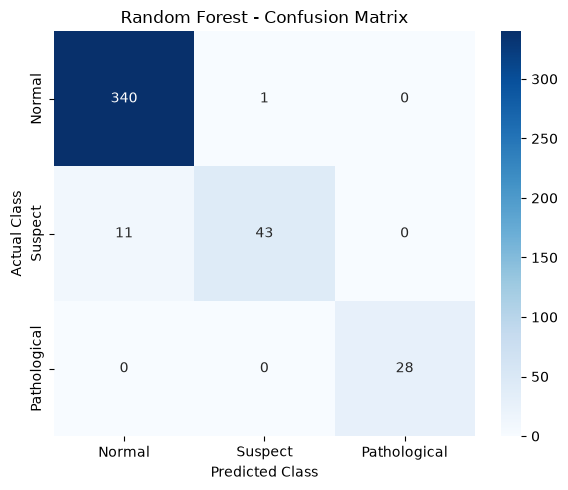

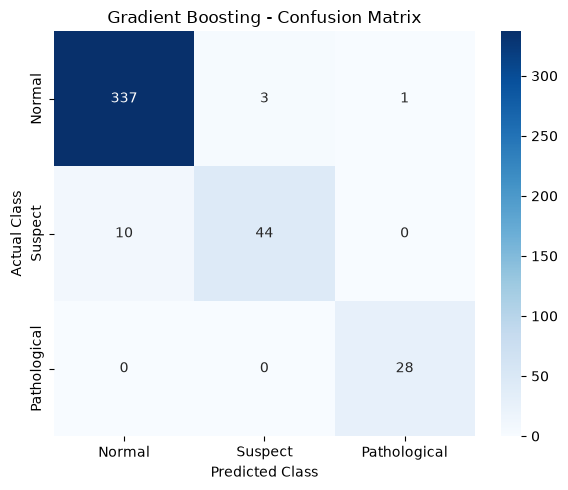

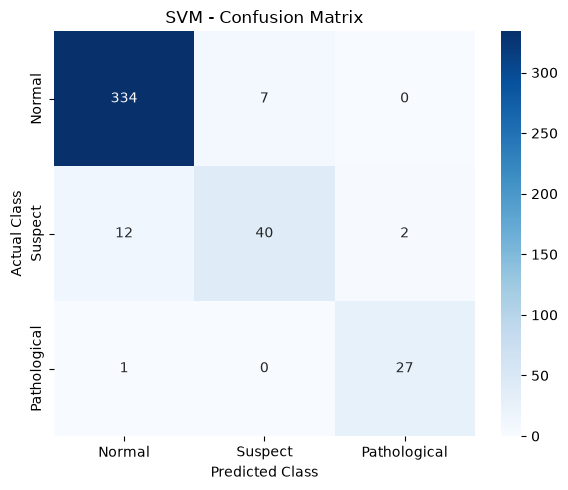

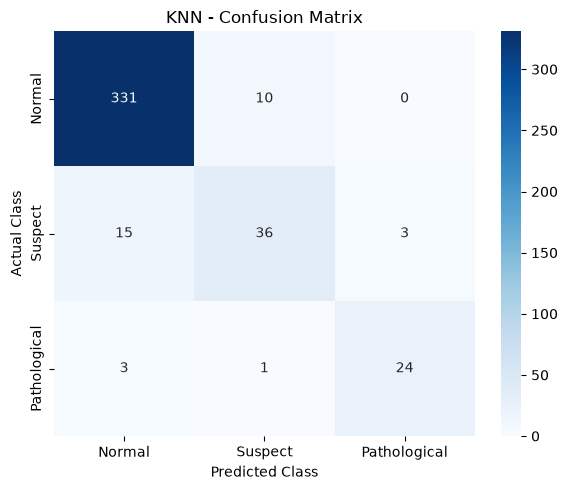

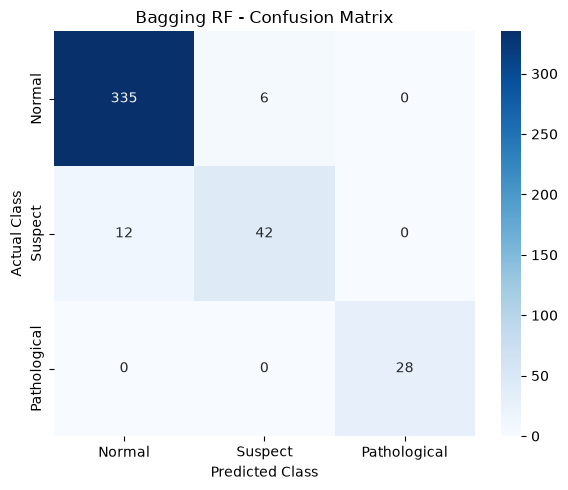

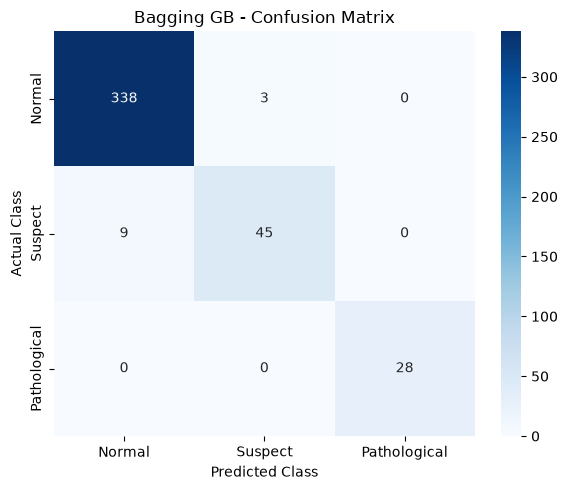

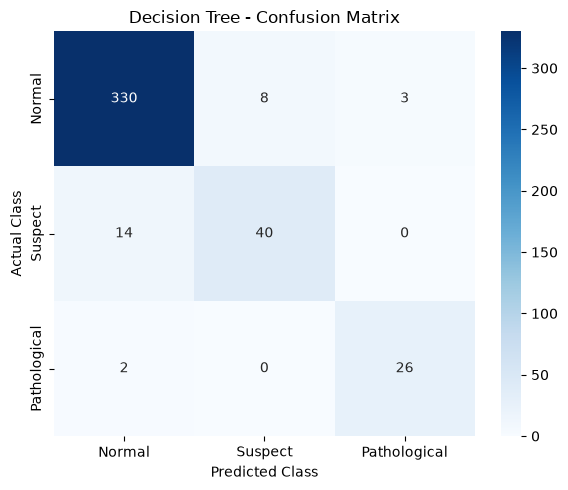

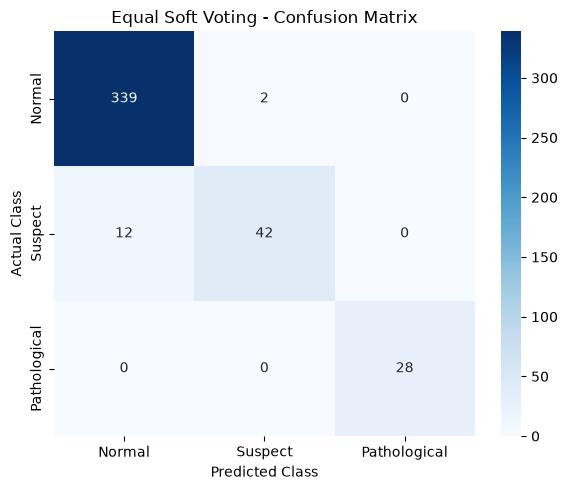

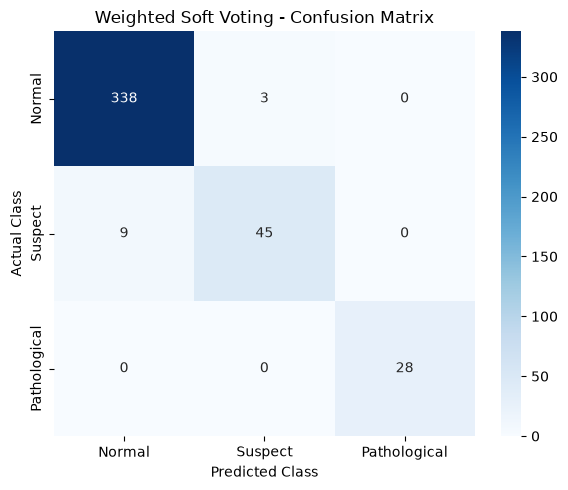

In [ ]:
#Confusion Matrix for each model

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Store all models and their predictions
models_predictions = {
    "Random Forest": rf_test_pred,
    "Gradient Boosting": gb_tuned_pred,
    "SVM": svm_test_pred,
    "KNN": knn_tuned_pred,
    "Bagging RF": bag_tuned_pred,
    "Bagging GB": bagging_gb_pred,
    "Decision Tree": dt_tuned_pred,
    "Equal Soft Voting": soft_voting_pred,
    "Weighted Soft Voting": weighted_voting_pred
}

# Class labels
class_labels = ["Normal", "Suspect", "Pathological"]

# Generate confusion matrix for each model
for model_name, predictions in models_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels
    )

    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(f"{model_name} - Confusion Matrix")

    plt.tight_layout()
    plt.show()

In [52]:
# Final evaluation table with
# Test Accuracy, CV Accuracy, Precision, Recall, and F1-Score

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Store models and predictions
models_predictions = {
    "Random Forest": rf_test_pred,
    "Gradient Boosting": gb_tuned_pred,
    "SVM": svm_test_pred,
    "KNN": knn_tuned_pred,
    "Bagging RF": bag_tuned_pred,
    "Bagging GB": bagging_gb_pred,
    "Decision Tree": dt_tuned_pred,
    "Equal Soft Voting": soft_voting_pred,
    "Weighted Soft Voting": weighted_voting_pred
}

# Create evaluation results
evaluation_results = []

for model_name, predictions in models_predictions.items():

    evaluation_results.append({
        "Model": model_name,
        "Test Accuracy (%)": accuracy_score(y_test, predictions) * 100,
        "Precision": precision_score(
            y_test, predictions, average="weighted"
        ),
        "Recall": recall_score(
            y_test, predictions, average="weighted"
        ),
        "F1-Score": f1_score(
            y_test, predictions, average="weighted"
        )
    })

# Convert to DataFrame
evaluation_results = pd.DataFrame(evaluation_results)

# Cross-validation accuracy
cv_scores = [
    rf_grid_search.best_score_ * 100,
    gb_grid_search.best_score_ * 100,
    svm_grid_search.best_score_ * 100,
    knn_grid_search.best_score_ * 100,
    bag_grid_search.best_score_ * 100,
    bagging_gb_grid_search.best_score_ * 100,
    dt_grid_search.best_score_ * 100,
    None,
    weighted_voting_grid.best_score_ * 100
]

evaluation_results["CV Accuracy (%)"] = cv_scores

# Round numerical values
evaluation_results = evaluation_results.round(2)

# Sort from highest to lowest Test Accuracy
evaluation_results = evaluation_results.sort_values(
    by="Test Accuracy (%)",
    ascending=False
)

# Reset index and start numbering from 1
evaluation_results.index = range(1, len(evaluation_results) + 1)

# Display final table
evaluation_results

,Model,Test Accuracy (%),Precision,Recall,F1-Score,CV Accuracy (%)
1,Random Forest,97.16,0.97,0.97,0.97,93.61
2,Weighted Soft Voting,97.16,0.97,0.97,0.97,95.15
3,Bagging GB,97.16,0.97,0.97,0.97,95.03
4,Gradient Boosting,96.69,0.97,0.97,0.97,95.27
5,Equal Soft Voting,96.69,0.97,0.97,0.97,NaN
6,Bagging RF,95.74,0.96,0.96,0.96,93.37
7,SVM,94.80,0.95,0.95,0.95,91.89
8,Decision Tree,93.62,0.93,0.94,0.93,92.25
9,KNN,92.43,0.92,0.92,0.92,91.30


### Saving the models

In [54]:
import joblib

# Save all trained models
joblib.dump(rf_best_model, "../04_models/random_forest_model.pkl")
joblib.dump(gb_tuned, "../04_models/gradient_boosting_model.pkl")
joblib.dump(svm_best_model, "../04_models/svm_model.pkl")
joblib.dump(knn_tuned, "../04_models/knn_model.pkl")
joblib.dump(bag_tuned, "../04_models/bagging_rf_model.pkl")
joblib.dump(best_bagging_gb, "../04_models/bagging_gb_model.pkl")
joblib.dump(dt_tuned, "../04_models/decision_tree_model.pkl")
joblib.dump(soft_voting, "../04_models/equal_soft_voting_model.pkl")
joblib.dump(best_weighted_voting, "../04_models/weighted_soft_voting_model.pkl")

# Save the scaler
joblib.dump(scaler, "../04_models/scaler.pkl")

print("All models and scaler saved successfully.")

All models and scaler saved successfully.


### Saving the evaluation results

In [55]:
# Save final model evaluation results

evaluation_results.to_csv(
    "../05_results/model_evaluation_results.csv",
    index=False
)

print("Model evaluation results saved successfully.")

Model evaluation results saved successfully.
